In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

print("Matrix A:\n", A)
print()
print("Matrix B:\n", B)

# matrix multiplication
C = A @ B
print(f"\nA @ B:\n{C}")

# determinant
det = np.linalg.det(A)
print(f"\nDet(A): {det:.2f}")

# inverse
inv = np.linalg.inv(A)
print(f"\nInverse of A:\n{inv}")

# eigenvalues
eigenvalues, eigenvectors = np.linalg.eig(A)
print(f"\nEigenvalues: {eigenvalues}")

Matrix A:
 [[1 2]
 [3 4]]

Matrix B:
 [[5 6]
 [7 8]]

A @ B:
[[19 22]
 [43 50]]

Det(A): -2.00

Inverse of A:
[[-2.   1. ]
 [ 1.5 -0.5]]

Eigenvalues: [-0.37228132  5.37228132]


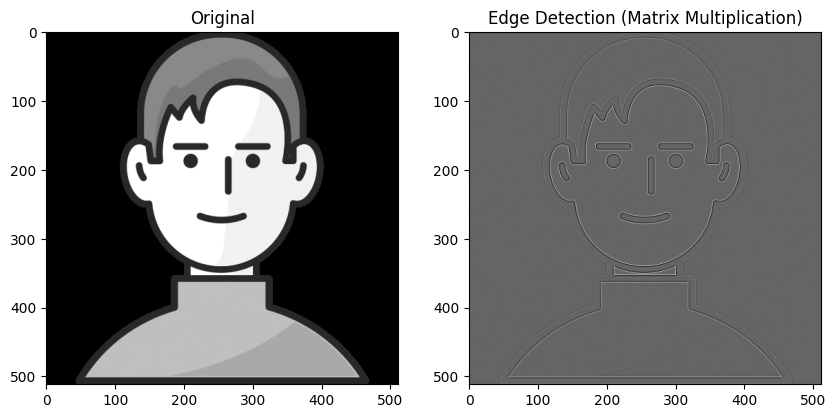

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load image
img = Image.open('../img/rotation_image.png').convert('L')  # Grayscale
img_array = np.array(img, dtype=np.float32)

# ============================================
# 1. Edge Detection using Matrix Multiplication
# ============================================

# Simple edge detection kernel
kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

# Apply convolution using matrix operations
def apply_filter(image, kernel):
    h, w = image.shape
    k = kernel.shape[0]
    pad = k // 2
    
    # Pad the image
    padded = np.pad(image, pad, mode='constant')
    result = np.zeros_like(image)
    
    # Matrix multiplication for each patch
    for i in range(h):
        for j in range(w):
            patch = padded[i:i+k, j:j+k]
            # Element-wise multiplication and sum (similar to A @ B)
            result[i, j] = np.sum(patch * kernel)
    
    return result

# Apply edge detection
edges = apply_filter(img_array, kernel)

# Display
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_array, cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(edges, cmap='gray')
axes[1].set_title('Edge Detection (Matrix Multiplication)')
plt.show()

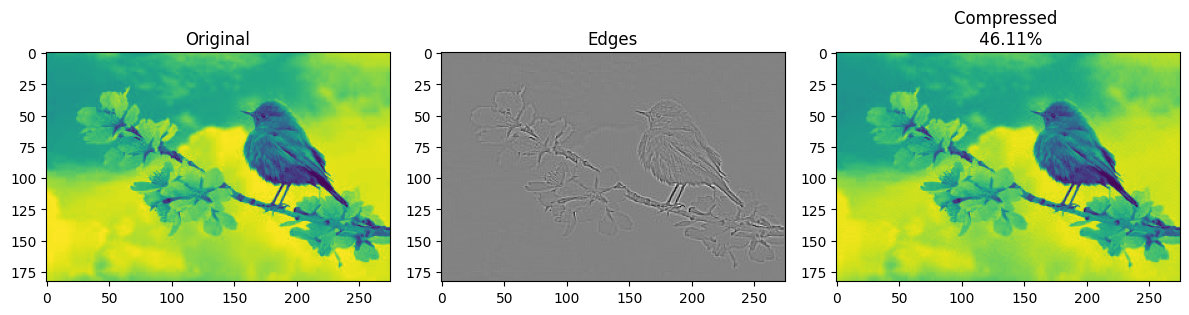

In [35]:
# Simple image operations using matrix operations
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load image
img = np.array(Image.open('../img/2026-06-06-01.jpeg').convert('L'), dtype=np.float32)

# 1. Edge Detection (Matrix Multiplication)
kernel = np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]])
edges = np.zeros_like(img)

for i in range(1, img.shape[0]-1):
    for j in range(1, img.shape[1]-1):
        patch = img[i-1:i+2, j-1:j+2]
        edges[i,j] = np.sum(patch * kernel)

# 4. PCA Compression (Eigenvalues)
# Simple: use only first 50% of singular values
U, S, Vt = np.linalg.svd(img)
k = len(S) // 2
compressed = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]

original_bytes = img.size * 8  # float64 = 8 bytes
compressed_bytes = U.shape[0] * k + k + k * Vt.shape[0] * 8 # compressed size (U: m*k, S: k, Vt: k*n)

# Display
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
ax =axes.flatten()
ax[0].imshow(img)
ax[0].set_title('Original')
ax[1].imshow(edges, cmap='gray') 
ax[1].set_title('Edges')
ax[2].imshow(compressed)
ax[2].set_title(f'Compressed \n {round((original_bytes - compressed_bytes) / original_bytes, 4) * 100}%')
plt.tight_layout()

plt.savefig('008_linear_algebra.png', dpi=80)
plt.show()